# Phase 3: Prescriptive Analysis
Prescriptive analysis looks at what should be done. Here, you want to group variables into "markers" (e.g., active vs. sedentary periods, high-carb vs. low-carb meals) and find actionable correlations.

## Marker Groups:

* Activity Markers: High steps/HR vs. Low steps/HR. Exercise typically increases insulin sensitivity, meaning the same dose of insulin will drop glucose much faster.
* Insulin-to-Carb Ratio (ICR): Correlating the bolus_volume_delivered to carb_input to see if the patient is dosing aggressively or conservatively.

*Correlation Insight*: Standard correlation (Pearson) fails on T1DM data because insulin and carbs have a lagged effect on glucose (insulin takes 15–30 minutes to start working and peaks at 90 minutes). You must calculate cross-correlations with time shifts.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_lagged_correlations(df):
    # Shift glucose back by 30, 60, and 90 minutes to see what correlates with future glucose
    # (Since our data is 5-min intervals, shift -6 means 30 mins in the future)
    df['glucose_in_30m'] = df['glucose'].shift(-6)
    df['glucose_in_60m'] = df['glucose'].shift(-12)
    
    # Calculate a rolling sum of active insulin/carbs over the last 2 hours
    df['carbs_last_2h'] = df['carb_input'].rolling(window=24, min_periods=1).sum()
    df['bolus_last_2h'] = df['bolus_volume_delivered'].rolling(window=24, min_periods=1).sum()
    df['steps_last_2h'] = df['steps'].rolling(window=24, min_periods=1).sum()
    
    cols_to_check = ['glucose', 'carbs_last_2h', 'bolus_last_2h', 'steps_last_2h', 'glucose_in_30m', 'glucose_in_60m']
    corr_matrix = df[cols_to_check].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Feature Correlation with Future Glucose Levels')
    plt.show()

In [3]:
import import_ipynb
from Data_Preprocessing_Cleaning import read_and_preprocess_data

In [4]:
cleaned_df = read_and_preprocess_data('/Users/jputha177@cable.comcast.com/Downloads/HUPA0002P.csv')

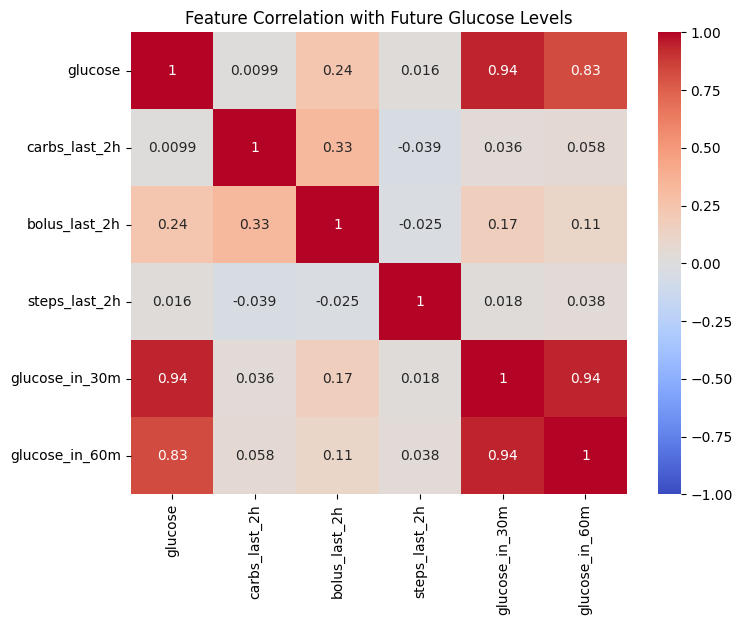

In [5]:
analyze_lagged_correlations(cleaned_df)